In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


In [30]:
# ============================================
# GLOBAL STYLE TEMPLATE
# ============================================

# Font
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 11

# Axes
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["axes.titleweight"] = "bold"

# Ticks
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10

# Legend
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["legend.fontsize"] = 10

# Figure
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["savefig.dpi"] = 300

# COLOR PALETTE — pick one:
# Single color for all single-series plots
MAIN_COLOR = "#2D6A9F"  # professional blue

# Multi-series colors (Plotly default)
COLORS = {
    "blue":   "#636EFA",
    "red":    "#EF553B", 
    "green":  "#00CC96",
    "purple": "#AB63FA",
    "orange": "#FFA15A",
    "teal":   "#19D3F3"
}

MAIN_COLOR = "#2D6A9F"
HIGHLIGHT_COLOR = "#EF553B"  # for Australia

In [48]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")

In [49]:
df = df[~df["date"].isin([1905, 1973, 1993, 0, 2019])]  # remove rows with irrelevant dates

In [10]:
print(type(df["date"]))

<class 'pandas.core.series.Series'>


In [16]:
df.head(5)

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants,is_mov
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1,False
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1,False
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2,False
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1,False
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1,False


In [ ]:
#Panel A: Bar chart — MOV events per 1000 sequences per year (2020-2025)
#Panel B: Horizontal bar — top 20 countries by MOV events (normalised)

# Temporal - yearly totals
df["is_mov"] = (df["LLR"] > 3) & (df["sum_contexts"] > 2)
yearly = df.groupby("date").agg(
    mov_count = ("is_mov", "sum"),
    total_seqs = ("node_id", "count")
).reset_index()

yearly["mov_per_1000"] = (yearly["mov_count"] / yearly["total_seqs"]) * 1000

print(yearly)
yearly = yearly.to_csv("/Users/reem/mov_seqs_per_year.tsv", sep="\t", index=False)

   date  mov_count  total_seqs  mov_per_1000
0  2020          2      392149      0.005100
1  2021         16     3512086      0.004556
2  2022        560     3359968      0.166668
3  2023        329     1051324      0.312939
4  2024         78      437747      0.178185
5  2025         16      182426      0.087707
6  2026          0         793      0.000000


In [41]:
# Country totals
country_totals = df.groupby("country").agg(
    mov_count=("is_mov", "sum"),
    total_seqs=("node_id", "count")  # adjust column name if needed
).reset_index()
country_totals["mov_per_1000"] = (country_totals["mov_count"] / country_totals["total_seqs"]) * 1000
filtered = country_totals[country_totals["total_seqs"] >= 100000]
print(filtered.nlargest(20, "mov_per_1000"))
filtered = filtered.to_csv("/Users/reem/mov_seqs_per_country_per_1000.tsv", sep="\t", index=False)

           country  mov_count  total_seqs  mov_per_1000
657      Australia        319      124062      2.571295
37152        Japan        138      326054      0.423243
33372        Italy         15      124167      0.120805
64541   SouthKorea         12      103908      0.115487
59397     Scotland         12      121283      0.098942
8977       Denmark         17      193496      0.087857
91447          USA        237     2903429      0.081628
13586      England         52      914424      0.056866
25863      Germany         20      504049      0.039679
65909        Spain          6      179423      0.033441
30439        India          7      209621      0.033394
4149        Brazil          2      197085      0.010148
16239       France          3      326006      0.009202
77871       Sweden          1      121480      0.008232
5164        Canada          2      316585      0.006317
51644  Netherlands          0      110463      0.000000


In [27]:
print(len(df[df["country"] == "France"]))

326006


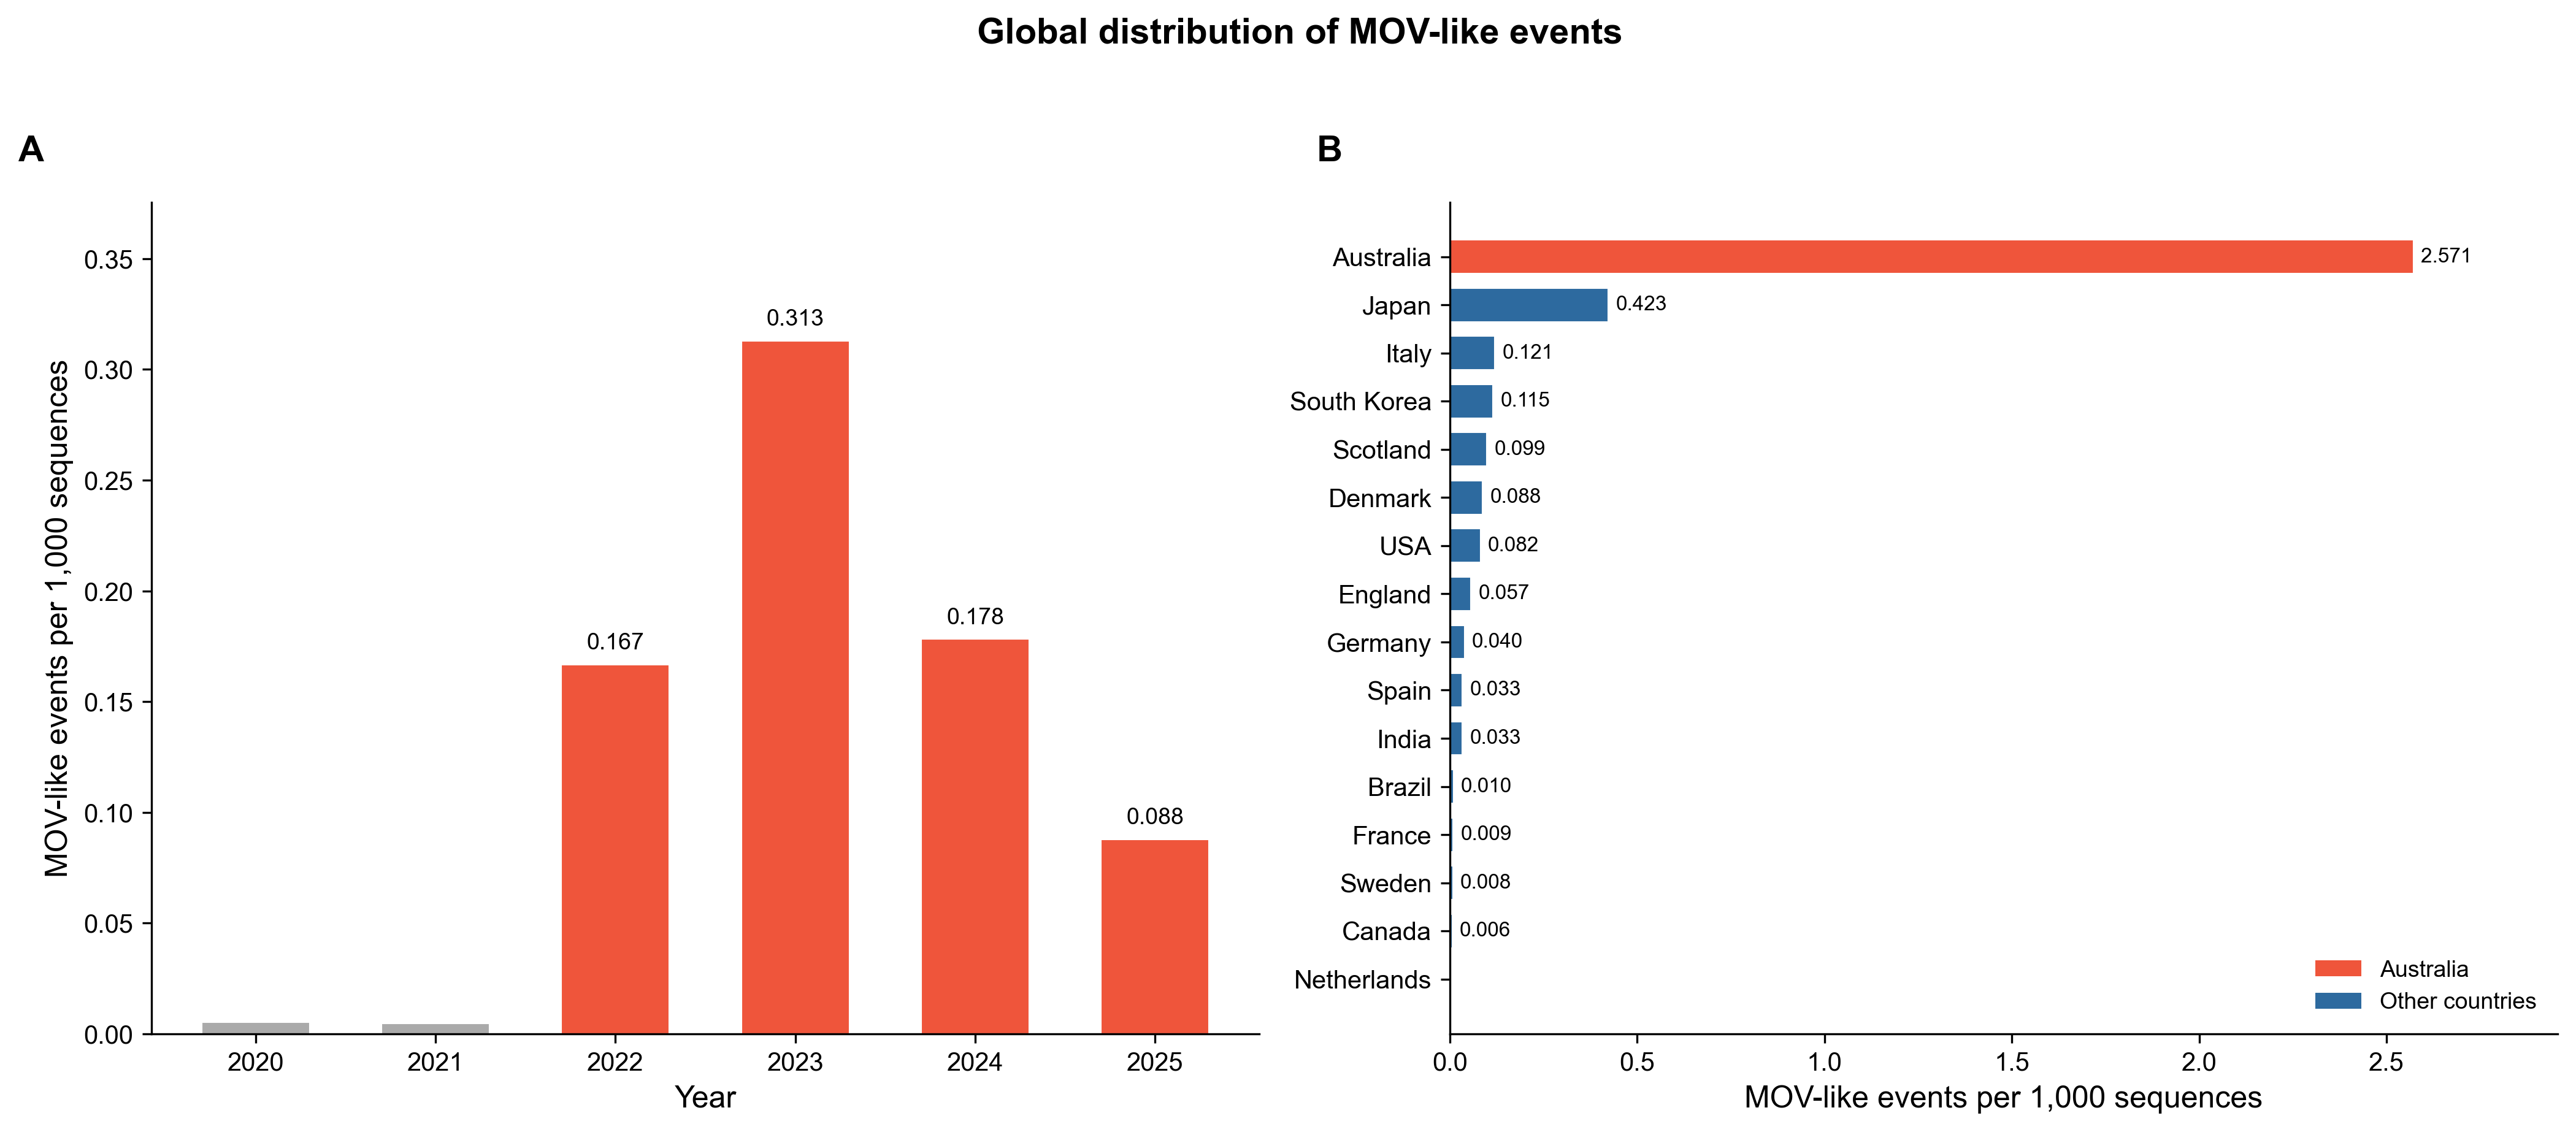

In [51]:
# DATA
# ============================================
yearly = pd.read_csv("/Users/reem/mov_seqs_per_year.tsv", sep="\t")

country = pd.read_csv("/Users/reem/mov_seqs_per_country_per_1000.tsv", sep = "\t")
country = country.sort_values("mov_per_1000", ascending=True)

# Fix country names
country["country"] = country["country"].str.replace("SouthKorea", "South Korea")\
                                        .str.replace("NewZealand", "New Zealand")\
                                        .str.replace("CzechRepublic", "Czech Republic")

# ============================================
# FIGURE
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel A: Temporal ----
# Remove 2026
yearly = yearly[~yearly["date"].isin([2026])]
colors_yearly = [HIGHLIGHT_COLOR if y >= 2022 else "#AAAAAA" 
                 for y in yearly["date"]]

bars = ax1.bar(yearly["date"].astype(str), 
               yearly["mov_per_1000"],
               color=colors_yearly,
               edgecolor="white",
               linewidth=0.5,
               width=0.6)

# Add value labels on bars
for bar, val in zip(bars, yearly["mov_per_1000"]):
    if val > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{val:.3f}",
                 ha="center", va="bottom",
                 fontsize=9, color="black")

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("MOV-like events per 1,000 sequences", fontsize=12)
ax1.set_ylim(0, max(yearly["mov_per_1000"]) * 1.2)
ax1.tick_params(axis="x", labelsize=10)
ax1.tick_params(axis="y", labelsize=10)

# Add annotation
ax1.annotate("",
            xy=("2023", 0.312939),
             xytext=("2024", 0.28),
             fontsize=9, color=HIGHLIGHT_COLOR)

ax1.text(-0.12, 1.05, "A", transform=ax1.transAxes,
         fontsize=14, fontweight="bold")

# ---- Panel B: Country ----
# Highlight Australia
colors_country = [HIGHLIGHT_COLOR if c == "Australia" else MAIN_COLOR 
                  for c in country["country"]]

ax2.barh(country["country"],
         country["mov_per_1000"],
         color=colors_country,
         edgecolor="white",
         linewidth=0.5,
         height=0.7)

# Add value labels
for i, (val, country_name) in enumerate(zip(country["mov_per_1000"], 
                                             country["country"])):
    if val > 0.005:
        ax2.text(val + 0.02, i,
                f"{val:.3f}",
                va="center", fontsize=8)

ax2.set_xlabel("MOV-like events per 1,000 sequences", fontsize=12)
ax2.set_ylabel("")
ax2.tick_params(axis="y", labelsize=10)
ax2.tick_params(axis="x", labelsize=10)
ax2.set_xlim(0, max(country["mov_per_1000"]) * 1.15)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=HIGHLIGHT_COLOR, label="Australia"),
    Patch(facecolor=MAIN_COLOR, label="Other countries")
]
ax2.legend(handles=legend_elements, frameon=False, 
           fontsize=9, loc="lower right")

ax2.text(-0.12, 1.05, "B", transform=ax2.transAxes,
         fontsize=14, fontweight="bold")

plt.suptitle("Global distribution of MOV-like events", 
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("/Users/reem/new_figs/mov_global_distribution.svg",
            dpi=300, bbox_inches="tight")
plt.show()